# Overview 

This notebook describes how to do in silico TF perturbation using GRN models. 

### Data
In this notebook, CellOracle uses two input data below for the GRN model construction.

- **Input data1: Oracle object**. 

- **Input data2: Links object**. `Links` object is a class to store GRN data. We need GRN models stored as a `Links` object for simulation. 

### What you can do
In this notebook, we perform two analyzes.

1. **in silico TF perturbation** to simulate cell identity shift. CellOracle uses the GRN model to simulate cell identity shift in response to TF perturbation. For this analysis, you need to construct GRN models in this notebook first.

2. **Compare simulation vector with development vectors**. In order to properly interpret the simulation results, it is very important to consider the natural direction of development. First, I will show you how to get a pseudo-time gradient vector field that represents the direction of development. Then, we compare the CellOracle TF perturbation simulation vector field with the development vector field by calculating the inner product score. See below for more information.
 
### Custom data class / object

In this notebook, CellOracle uses four custom classes, `Oracle`, `Links`, `Gradient_calculator`, and `Oracle_development_module`.

- `Oracle` is the main class in the CellOracle package. It will do almost all calculations of GRN model construction and TF perturbation simulation. 

- `Links` is a class to store GRN data. 

- `Gradient_calculator` calculates development vector field using pseudotime information. We need the pseudotime data for this calculation. Please see another notebook how to get pseudotime data.

- `Oracle_development_module` integrates `Oracle` object data and `Gradient_calculator` object data to analyze how TF perturbation affects on the developmental process. It have many visualization functions.


# Import libraries

In [6]:
# 0. Import
import os
from re import search
from dfply import *
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from pathlib import Path

This notebook was made with celloracle version 0.7.0.
Please use celloracle>=0.7.0. Otherwise you may get an error.

In [73]:
import celloracle as co
co.__version__

In [3]:
#plt.rcParams["font.family"] = "arial"
plt.rcParams["figure.figsize"] = [6,6]
%config InlineBackend.figure_format = 'retina'
plt.rcParams["savefig.dpi"] = 600

%matplotlib inline

# Load settings

In [74]:
if search("ricard", os.uname()[1]):
    exec(open('/Users/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/utils.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/rna_atac/gene_regulatory_networks/GRN/functions/GRN_utils.py').read())
elif search("ebi", os.uname()[1]):
    exec(open('/homes/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/utils.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/rna_atac/gene_regulatory_networks/GRN/functions/GRN_utils.py').read())
elif search("Workstation", os.uname()[1]):
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/settings.py').read())
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/utils.py').read())
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/rna_atac/gene_regulatory_networks/GRN/functions/GRN_utils.py').read())
else:
    exit("Computer not recognised")

## Define I/O

In [9]:
io["outdir"] = Path(io["basedir"]) / "results/rna_atac/GRN/trajectories/blood_trajectory/"

In [10]:
io['blood_chip_oracle'] = io['outdir'] / "blood_chip.celloracle.oracle"
io['blood_chip_links'] = io['outdir'] / 'blood_chip.celloracle.links'
io['blood_chip_velocity'] = io['outdir'] / 'blood_chip_velocity.celloracle.oracle'

## Define options 

scanpy options

In [11]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(6, 5), facecolor='white')

In [12]:
opts["celltypes"] = [
   "Haematoendothelial_progenitors",
   "Blood_progenitors_1",
   "Blood_progenitors_2",
   "Erythroid1",
   "Erythroid2",
   "Erythroid3"
]

# 1. Load data
## 1.1. Load processed oracle object

Load the oracle object. See the previous notebook for the notes on how to prepare the oracle object.

In [14]:
# oracle = co.load_hdf5("ORACLE OBJECT PATH")
oracle = co.load_hdf5(str(io['blood_chip_oracle']))

In [15]:
oracle

Oracle object

Meta data
    celloracle version used for instantiation: 0.7.5
    n_cells: 2442
    n_genes: 2064
    cluster_name: trajectory
    dimensional_reduction_name: Diffmap_embedding
    n_target_genes_in_TFdict: 1248 genes
    n_regulatory_in_TFdict: 560 genes
    n_regulatory_in_both_TFdict_and_scRNA-seq: 143 genes
    n_target_genes_both_TFdict_and_scRNA-seq: 1248 genes
    k_for_knn_imputation: 61
Status
    Gene expression matrix: Ready
    BaseGRN: Ready
    PCA calculation: Done
    Knn imputation: Done
    GRN calculation for simulation: Not finished

## 1.2. Load inferred GRNs

In the previous notebook, we calculated GRNs. Now, we will use these GRNs for simulation.
We import GRNs which were saved in the Links object.


In [16]:
links = co.load_hdf5(file_path=str(io['blood_chip_links']))
links

# 2. Make predictive models for simulation

We will fit ridge regression models again.
This process takes less time than the GRN inference in the previous notebook because we use already filtered GRN models.

In [17]:
links.filter_links()
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle.fit_GRN_for_simulation(alpha=10, use_cluster_specific_TFdict=True)

fitting GRN again...
calculating GRN in blood


  0%|          | 0/2064 [00:00<?, ?it/s]

genes_in_gem: 2064
models made for 1035 genes


# 3. in silico TF Perturbation analysis

Next, we will simulate the TF perturbation effects on cell identity to investigate its function and regulatory mechanism.
See the celloracle paper for the details and scientific premise on the algorithm.


In this notebook, we'll show an example of the simulation; we'll simulate knock-out of Gata1 gene in the blood trajectory. 

Previous studies have shown that Gata1 is one of the TFs that regulates cell fate decisions in myeloid progenitors. Additionally, Gata1 has been shown to affect erythroid cell differentiation. 

Here, we will analyze Gata1 for the demonstration of celloracle; Celloracle try to recapitulate the previous findings of Gata1 gene above.

## 3.1. Check gene expression pattern.

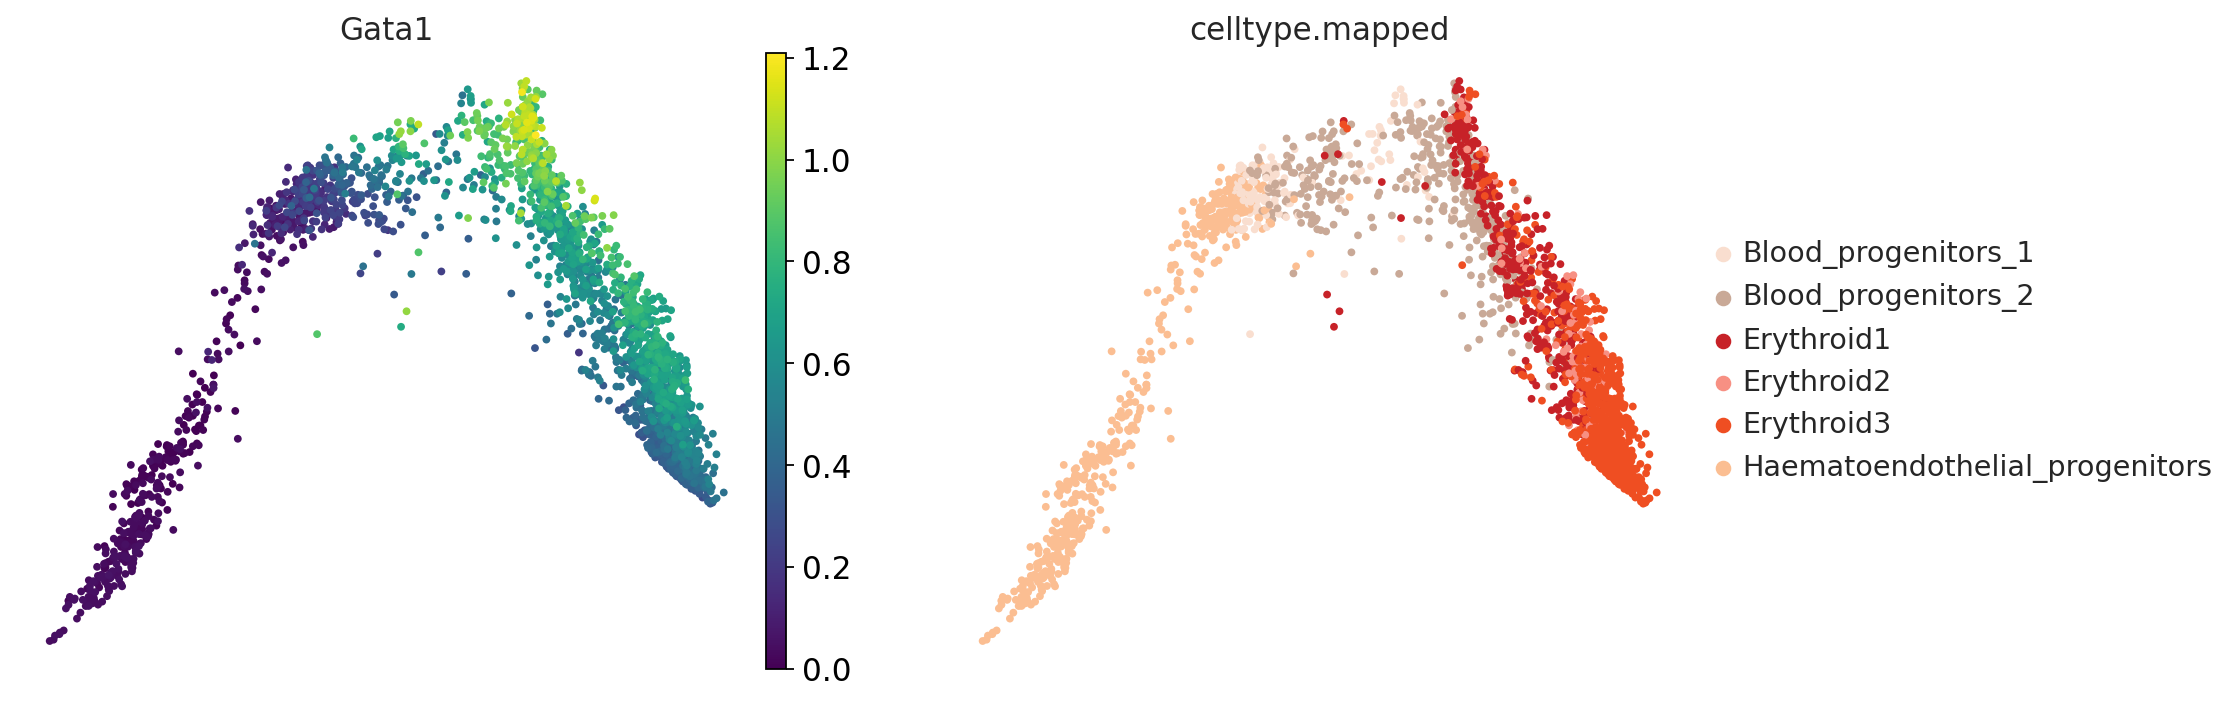

In [21]:
# Check gene expression 
goi = "Gata1"
sc.pl.diffmap(oracle.adata, color=[goi, 'celltype.mapped'],
                 layer="imputed_count", use_raw=False, cmap="viridis")

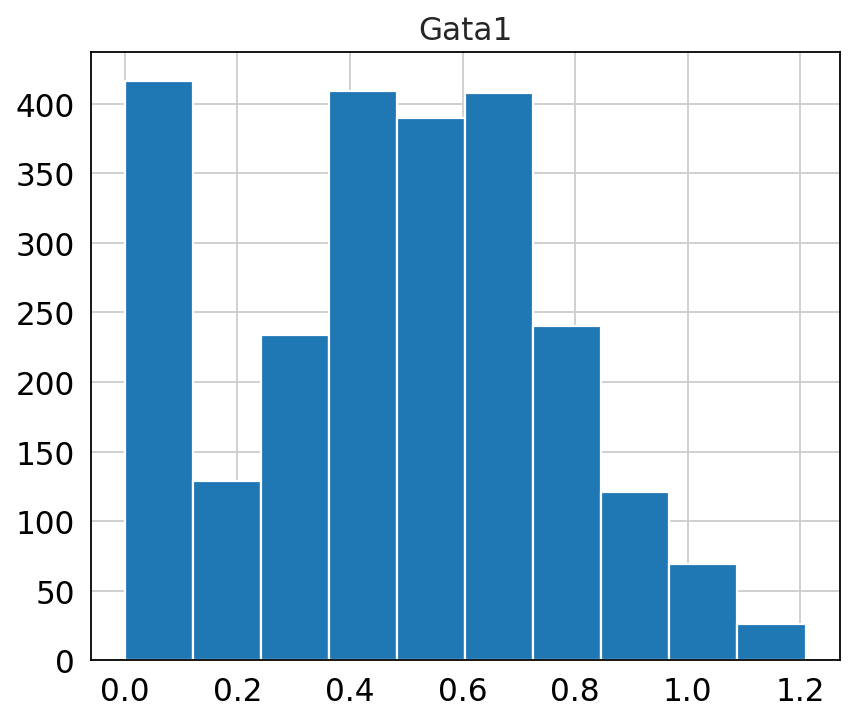

In [22]:
# Plot gene expression in histogram
sc.get.obs_df(oracle.adata, keys=[goi], layer="imputed_count").hist()
plt.show()

## 3.2. calculate future gene expression after perturbation.

- You can use any gene expression value to enter in silico perturbations, but please avoid extremely high values that are far from the natural gene expression range. The upper limit allowed is twice the maximum gene expression.


Here we simulate Gata1 KO; we predict what happens to the cells if Gata1 gene expression changed into 0.

In [23]:
# Enter perturbation conditions to simulate signal propagation after the perturbation.
oracle.simulate_shift(perturb_condition={goi: 0.0},
                      n_propagation=3)

## 3.3. calculate transition probability between cells

- The steps above simulated global future gene expression shift after perturbation. This prediction is based on iterative calculations of signal propagation within the GRN. Please look at our paper for more information.

- The next step is to calculate the probability of cell state transitions based on the simulation data. You can use the transition probabilities between cells to predict how cells will change after a perturbation.

- This transition probability will be used later.


In [24]:
# Get transition probability
oracle.estimate_transition_prob(n_neighbors=200,
                                knn_random=True, 
                                sampled_fraction=1)

# Calculate embedding 
oracle.calculate_embedding_shift(sigma_corr = 0.05)

# 4. Visualization
## 4.1. Quiver plot: Show the direction of cell transition at single cell resolution

### Caution: It is very important to find optimal `scale` parameter.

- We need to adjust the `scale` parameter. Please seek to find the optimal  `scale` parameter that provides good visualization.

- If you don't see any vector, you can try the smaller `scale` parameter to magnify vector length. However, if you see large vectors in the right panel, which is a randomized simulation, it means that the scale parameters are too small.


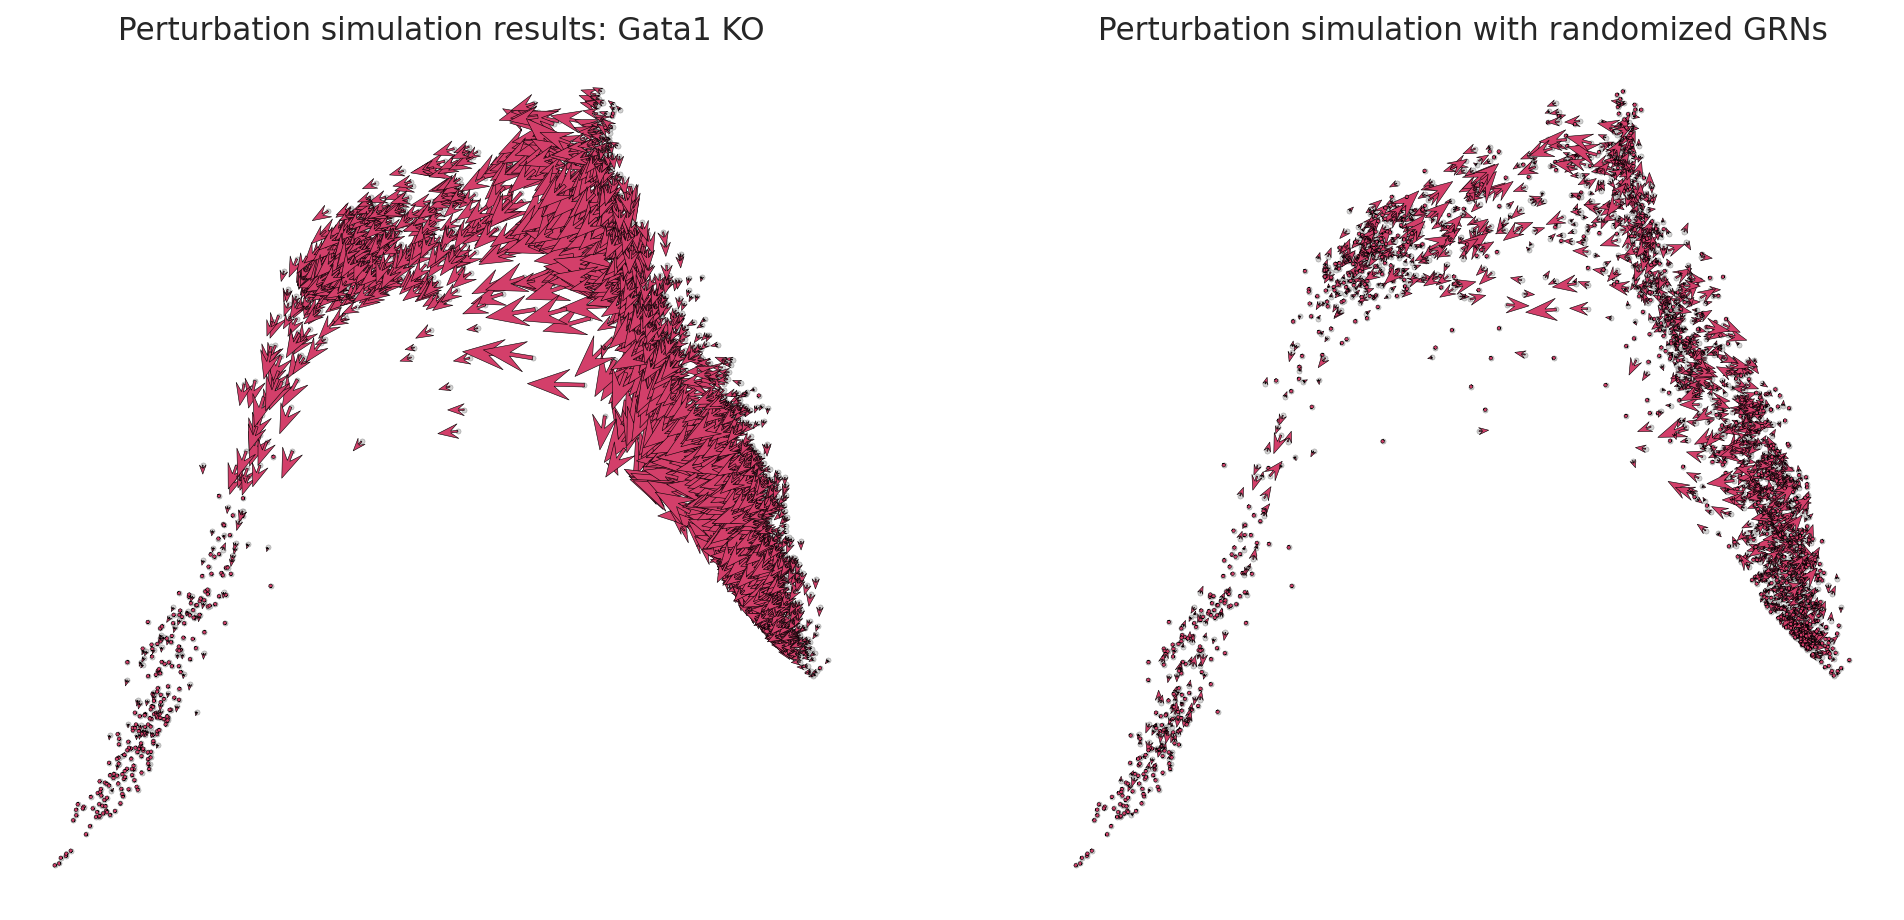

In [25]:
fig, ax = plt.subplots(1, 2,  figsize=[15, 7])

scale = 25
# Show quiver plot
oracle.plot_quiver(scale=scale, ax=ax[0])
ax[0].set_title(f"Perturbation simulation results: {goi} KO")

# Show quiver plot that was calculated with randomized GRN.
oracle.plot_quiver_random(scale=scale, ax=ax[1])
ax[1].set_title(f"Perturbation simulation with randomized GRNs")

plt.show()

## 4.2. Vector field graph

We can visualize simulation result as a vector field graph. Single cell transition vectors are grouped by grid point.

### 4.2.1  Find parameters for n_grid and min_mass
`n_grid`: Number of grid point.

`min_mass`: Threshold value for the cell density
The appropriate values for these parameters depends on the data. Please find appropriate values as follows.
 


In [26]:
# n_grid = 40 is a good point to start with.
n_grid = 40 
oracle.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)

Please run `oracle.suggest_mass_thresholds()`to find appropriate `min_mass` parameter.
It will give you some examples.

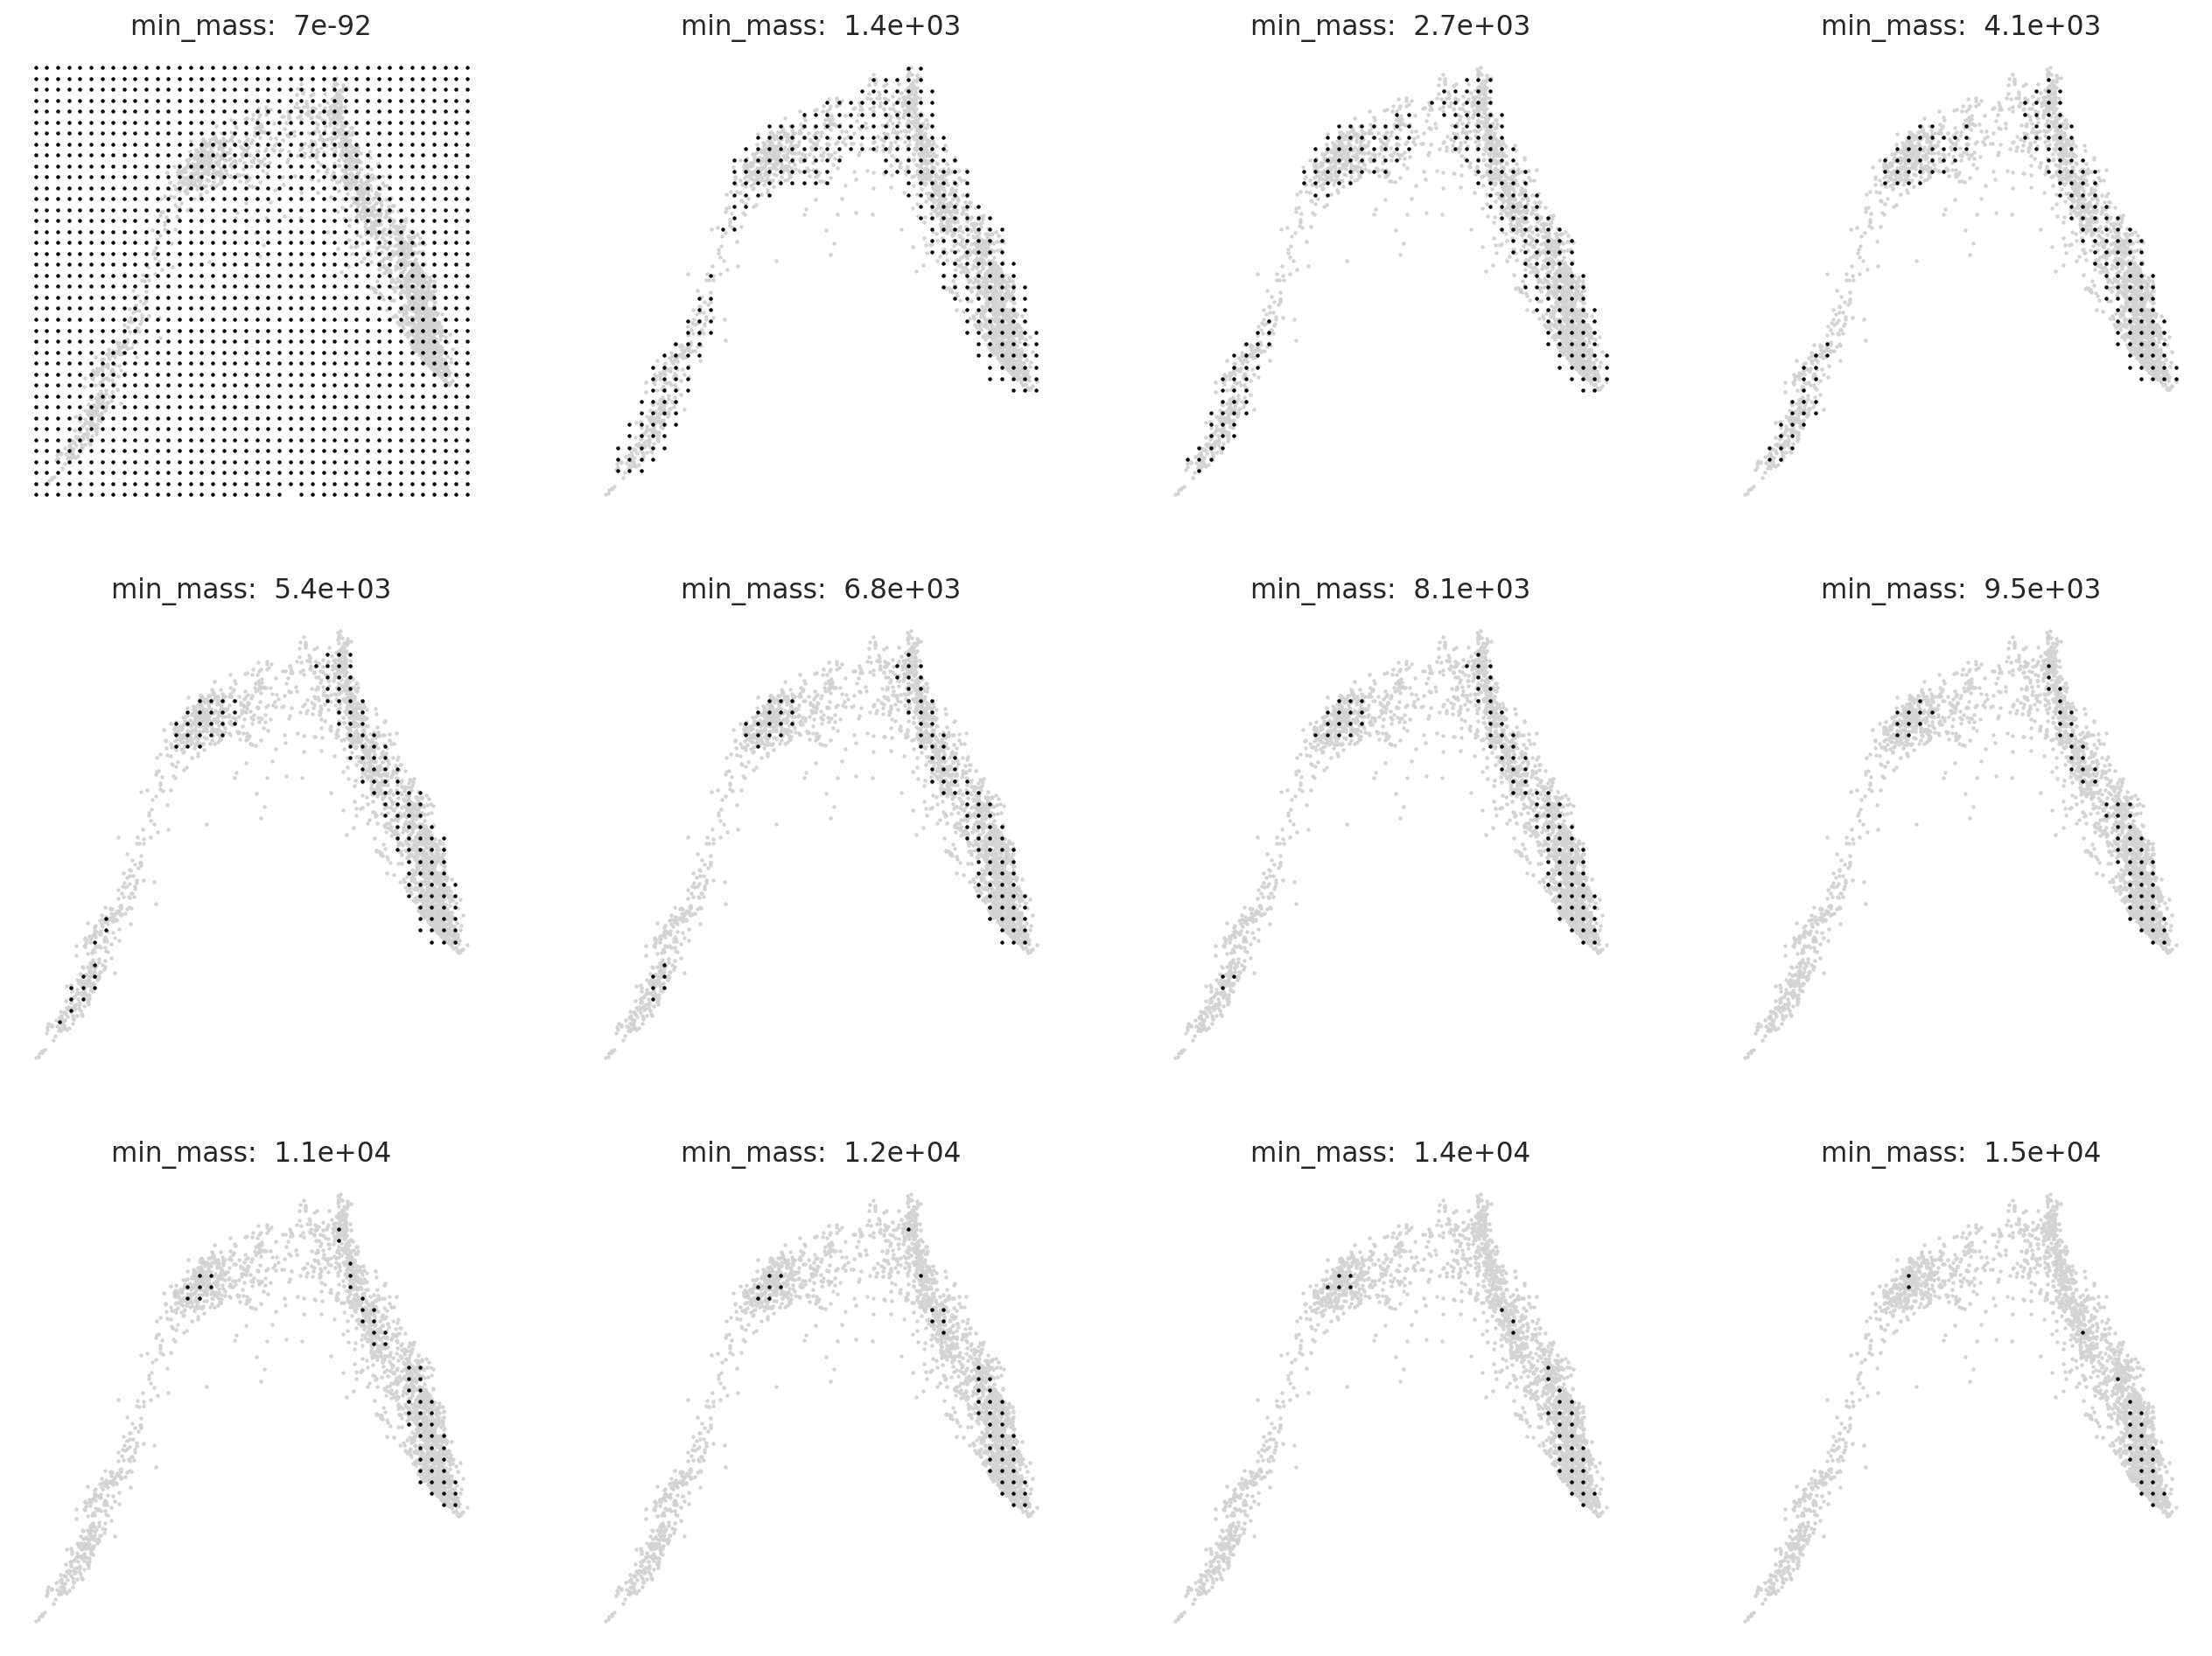

In [27]:
# Search for best min_mass.
oracle.suggest_mass_thresholds(n_suggestion=12)

According to the results, the appropriate `min_mass` is around 0.011.

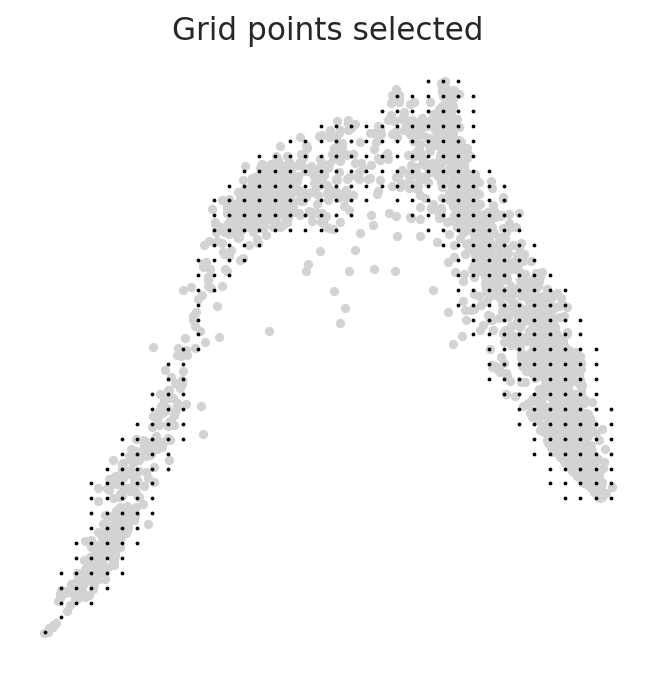

In [50]:
min_mass = 1e3
oracle.calculate_mass_filter(min_mass=min_mass, plot=True)

### 4.2.2  Plot vector fields

- Again, we need to adjust the `scale` parameter. Please seek to find the optimal `scale` parameter that provides good visualization.

- If you don't see any vector, you can try the smaller `scale` parameter to magnify vector length. However, if you see large vectors in the right panel, which is a randomized simulation, it means that the scale parameters are too small.



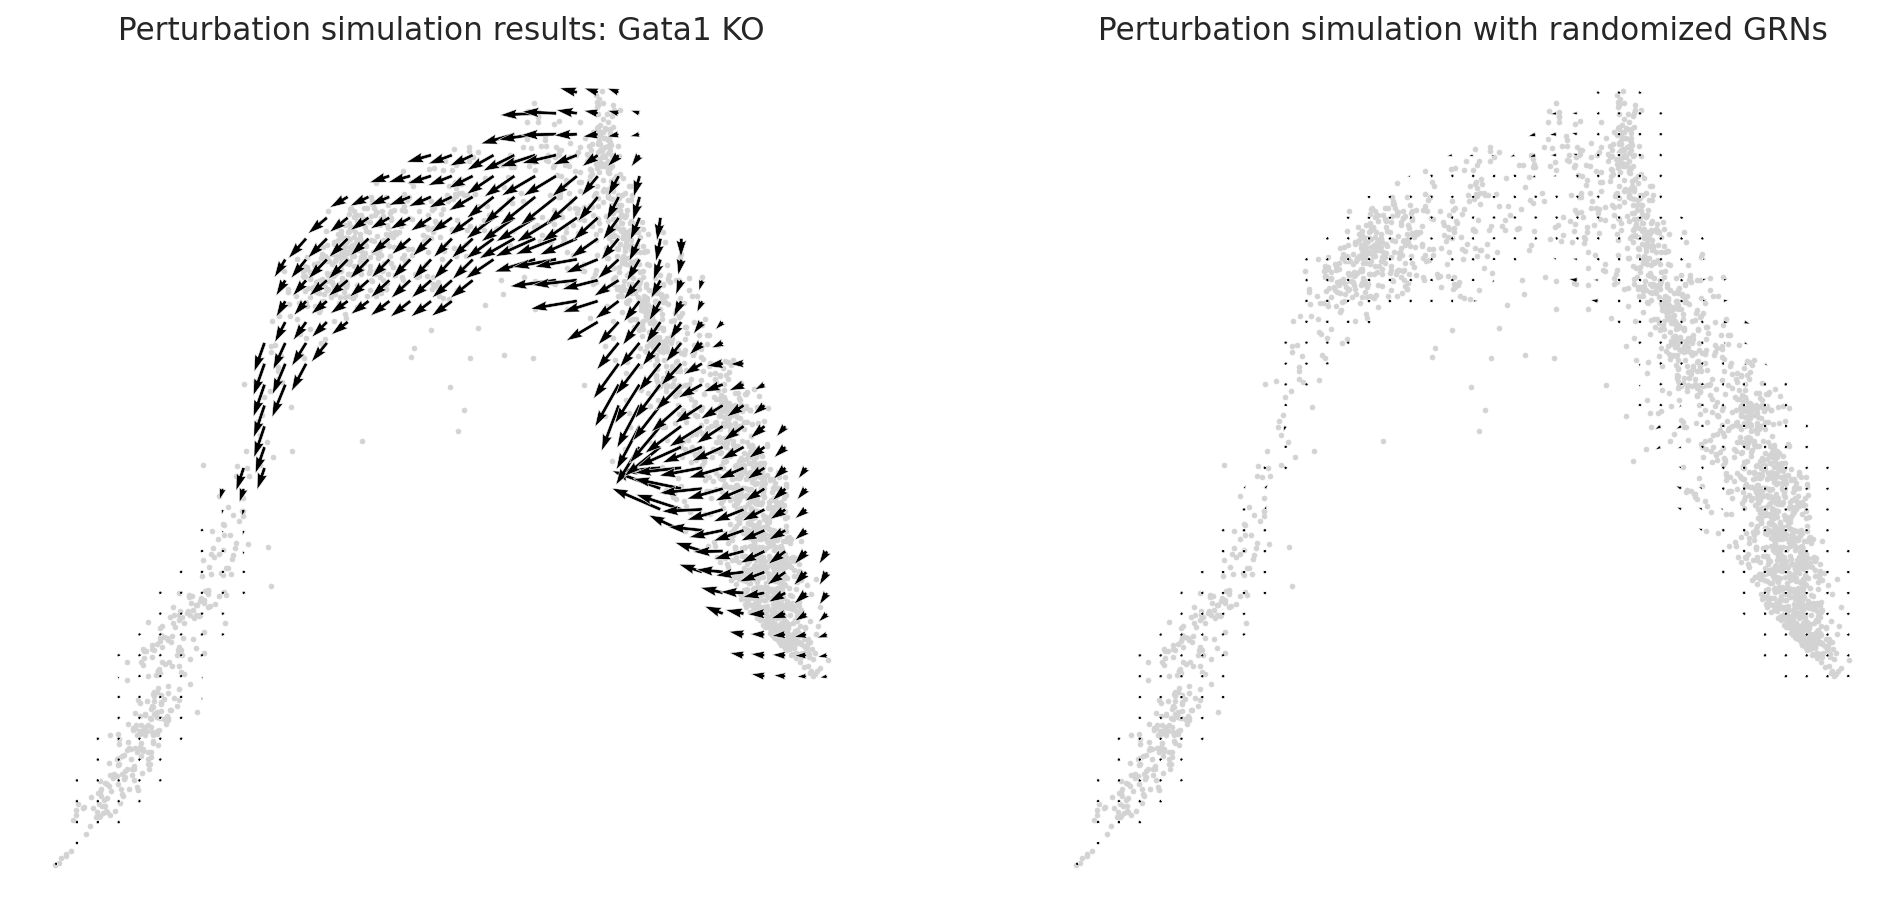

In [51]:
fig, ax = plt.subplots(1, 2,  figsize=[15, 7])

scale_simulation = 20
# Show quiver plot
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax[0])
ax[0].set_title(f"Perturbation simulation results: {goi} KO")

# Show quiver plot that was calculated with randomized GRN.
oracle.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1])
ax[1].set_title(f"Perturbation simulation with randomized GRNs")

plt.show()

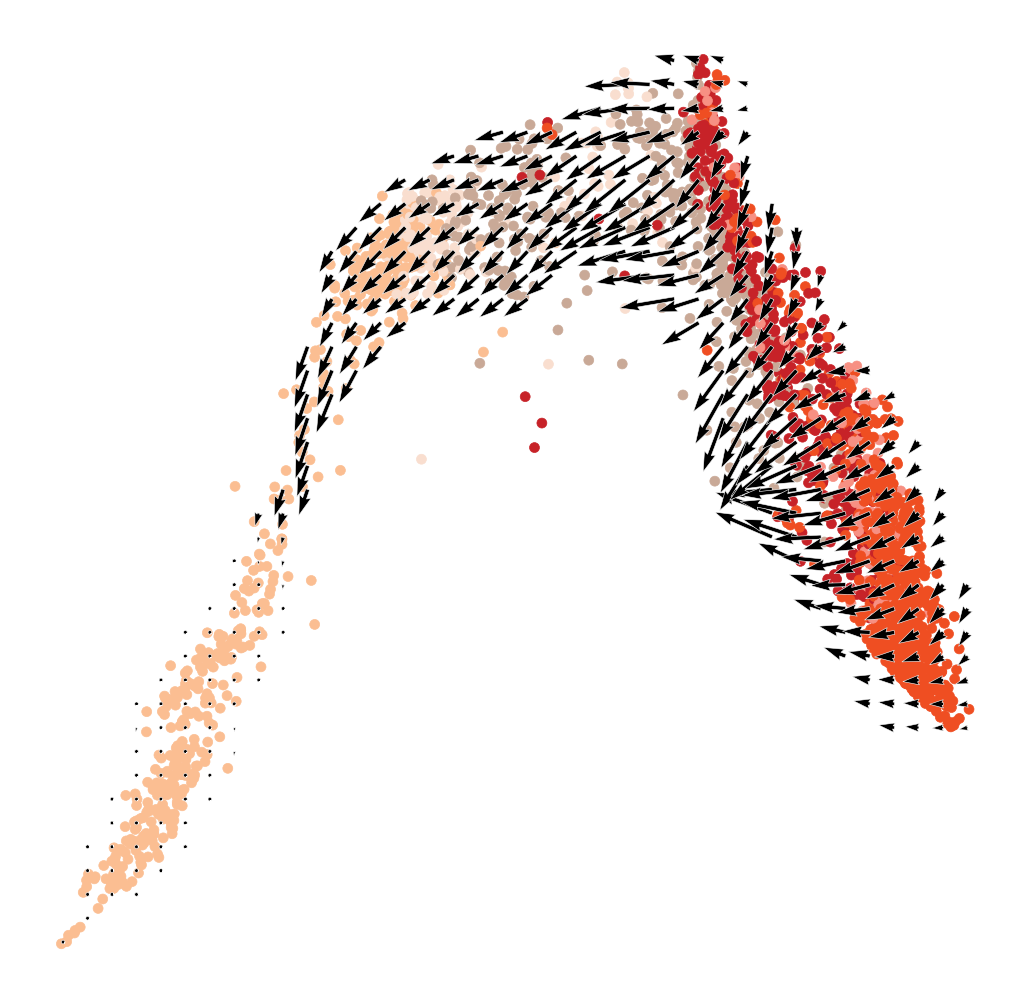

In [52]:
fig, ax = plt.subplots(figsize=[8, 8])
plot_cluster(oracle,ax=ax, s=20,color='celltype.mapped')
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax, show_background=False)

# 5. Compare simulation vector with development vectors


## 5.0. Method overview

- As shown above, we can use celloracle's simulation to infer how TF perturbations affect cell identity. The simulation results are provided in the form of a vector field map.

- To interpret the results, it is necessary to take into account the direction of natural differentiation. We will compare the simulated perturbation vectors with the development vector. By comparing them, we can intuitively understand how TF is involved in cell fate determination during development. This perspective is also important for the estimation of experimental perturbation results

- Here, we show an example to calculate the vector field of development using **pseudotime gradient**. In short, the process is as follows.
 
 1. Transfer **pseudotime data** into n x n grid point.

 2. Calculate the 2D gradient of pseudotime to get vector field

 3. Compare in silico TF perturbation vector field with development vector field by calculating inner product between these two vectors.


-  Also, there are many other options to get vector field of development flow from scRNA-seq data, and you can select another option. For example, RNA velocity analysis is a good way to estimate the direction of cell differentiation. Choose the method that best suits your data.



## 5.1 Prepare pseudotime data

In the analysis below, we need to use **pseudotime** data. Pseudotime data is included in the demo data. **If you try to analyze your scRNA-seq data, please calculate pseudotime before starting this analysis.**

## 5.2. Check data

We use pseudotime data for an input of this analysis.
Pleas calculate continuous pseudotime in advance. Please look at another notebook for details on how to calculate pseudotime.

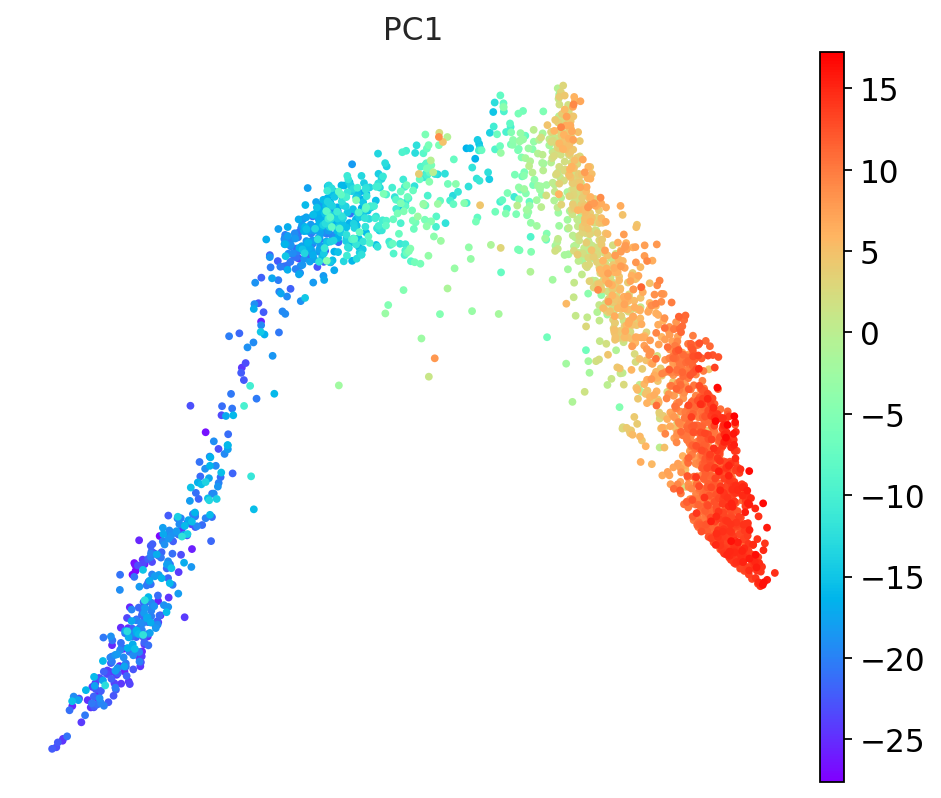

In [45]:
# Visualize pseudotime
fig, ax = plt.subplots(figsize=[7,6])

sc.pl.embedding(adata=oracle.adata, basis=oracle.embedding_name, ax=ax, cmap="rainbow",
                color=["PC1"])

## 5.3. Make Gradient_calculator object

In [47]:
from celloracle.applications import Gradient_calculator

# Instantiate Gradient calculator object
gradient = Gradient_calculator(oracle_object=oracle, pseudotime_key="PC1")

We need to select `n_grid` and `min_mass` to make grid point.
`n_grid`: Number of grid point.

We already know approproate values for them. Please set the same values as step 4.2.1 above.


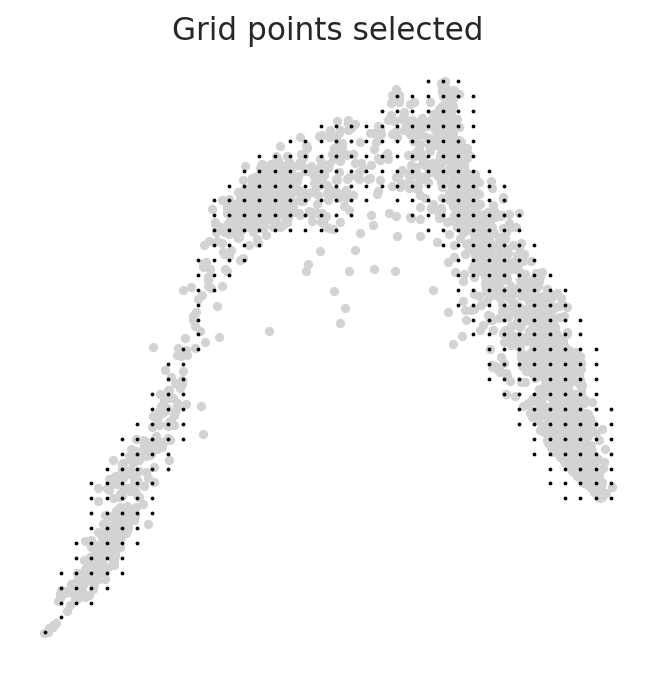

In [53]:
gradient.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)
gradient.calculate_mass_filter(min_mass=min_mass, plot=True)

## 5.4 Transfer pseudotime values to the grid points.

Next, we will transfer pseudotime data into grid points. For this calculation we can chose two method.

- knn: K-Nearesr Neighbor regressor. You need to set number of neighbor.
  Please adjust `n_knn` searching for best results.

 `gradient.transfer_data_into_grid(args={"method": "knn", "n_knn":50})`



- polynomial: Polynomial regression using x-axis and y-axis of dimensional reduction space.

 In general, this method will be more robust. Please use this method if k-nn does not work.
 `n_poly` is the number of degree for the polynomial regression model. Please try to find appropriate`n_poly` searching for best results.
 
 `gradient.transfer_data_into_grid(args={"method": "polynomial", "n_poly":3})`

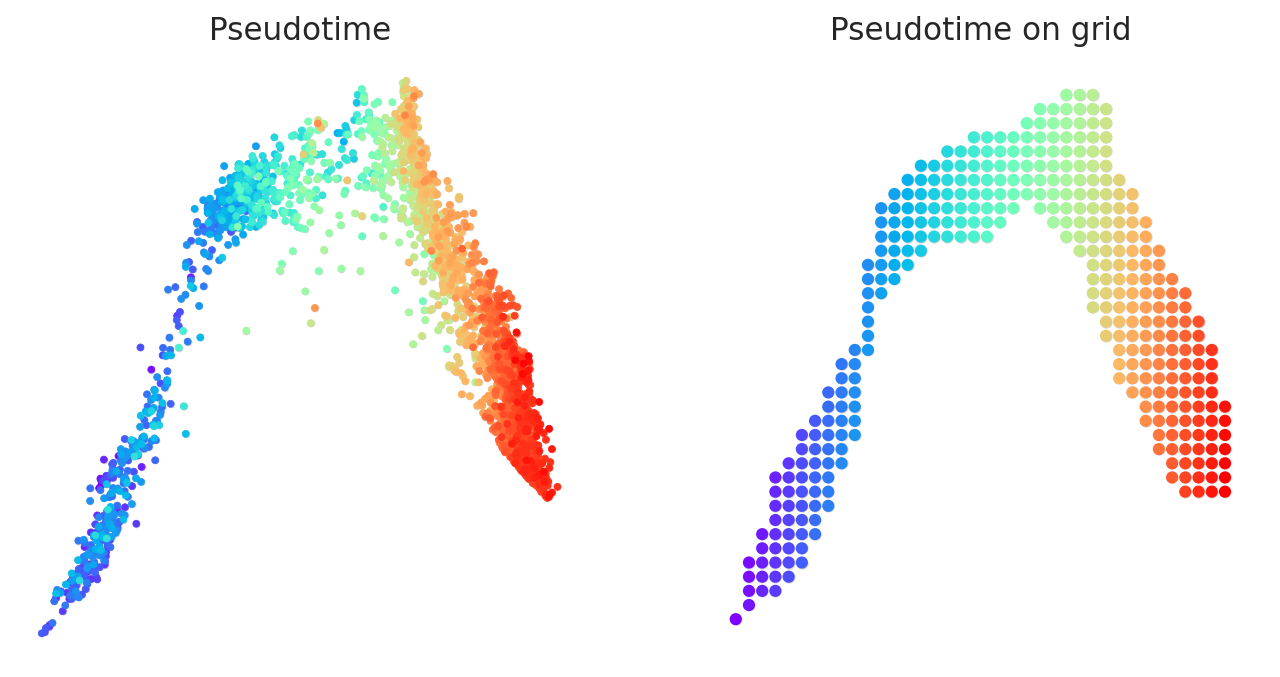

In [54]:
gradient.transfer_data_into_grid(args={"method": "polynomial", "n_poly":3}, plot=True)

## 5.5. Calculate Gradient vectors

Calculate 2D vector map that represents the gradient of pseudotime. After the gradient calculation, the length of the vector will be normalized automatically.

Please adjust `scale` parameter to adjust vector length.

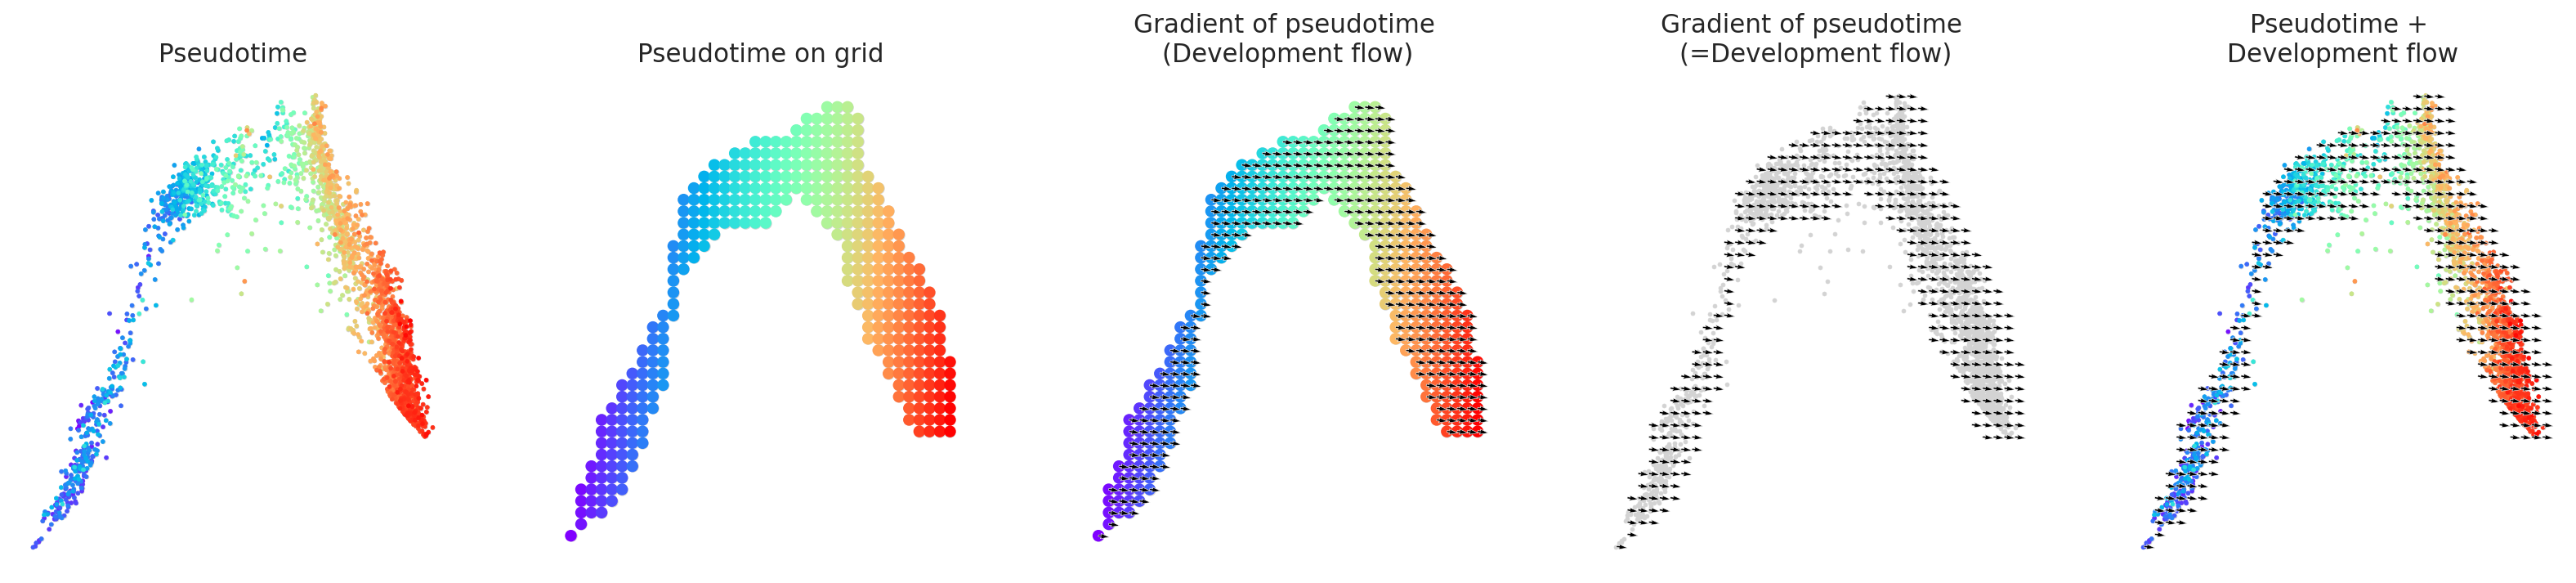

In [55]:
# Calculate graddient
gradient.calculate_gradient()

# Show results
scale_dev = 40
gradient.visualize_results(scale=scale_dev, s=5)

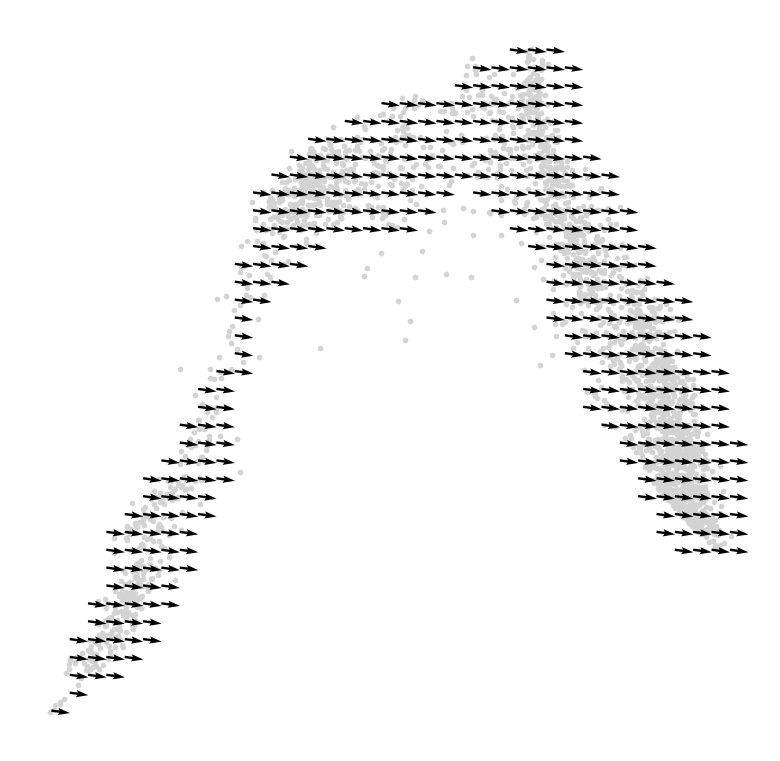

In [56]:
# Visualize results
fig, ax = plt.subplots(figsize=[6, 6])
gradient.plot_dev_flow_on_grid(scale=scale_dev, ax=ax)

In [26]:
# Save gradient object if you want.
#gradient.to_hdf5("../data/Paul_etal.celloracle.gradient")

## 5.6. Calculate Inner product between two vectors

We will use the inner product to compare the 2D vector map of perturb-simulation and development quantitatively.
In summary, 
- **<span style="color: blue; "> a negative inner product</span>** means that perturbation might **<span style="color: blue; "> block differentiation </span>**.
- **<span style="color: red; "> a positive inner product</span>** means that perturbation might **<span style="color: red; "> promote differentiation </span>**.



In [77]:
from celloracle.applications import Oracle_development_module

# Make Oracle_development_module to compare two vector field
dev = Oracle_development_module()

# Load development flow
dev.load_differentiation_reference_data(gradient_object=gradient)

# Load simulation result
dev.load_perturb_simulation_data(oracle_object=oracle)


# Calculate inner produc scores
dev.calculate_inner_product()
dev.calculate_digitized_ip(n_bins=10)

## 5.7 Show results

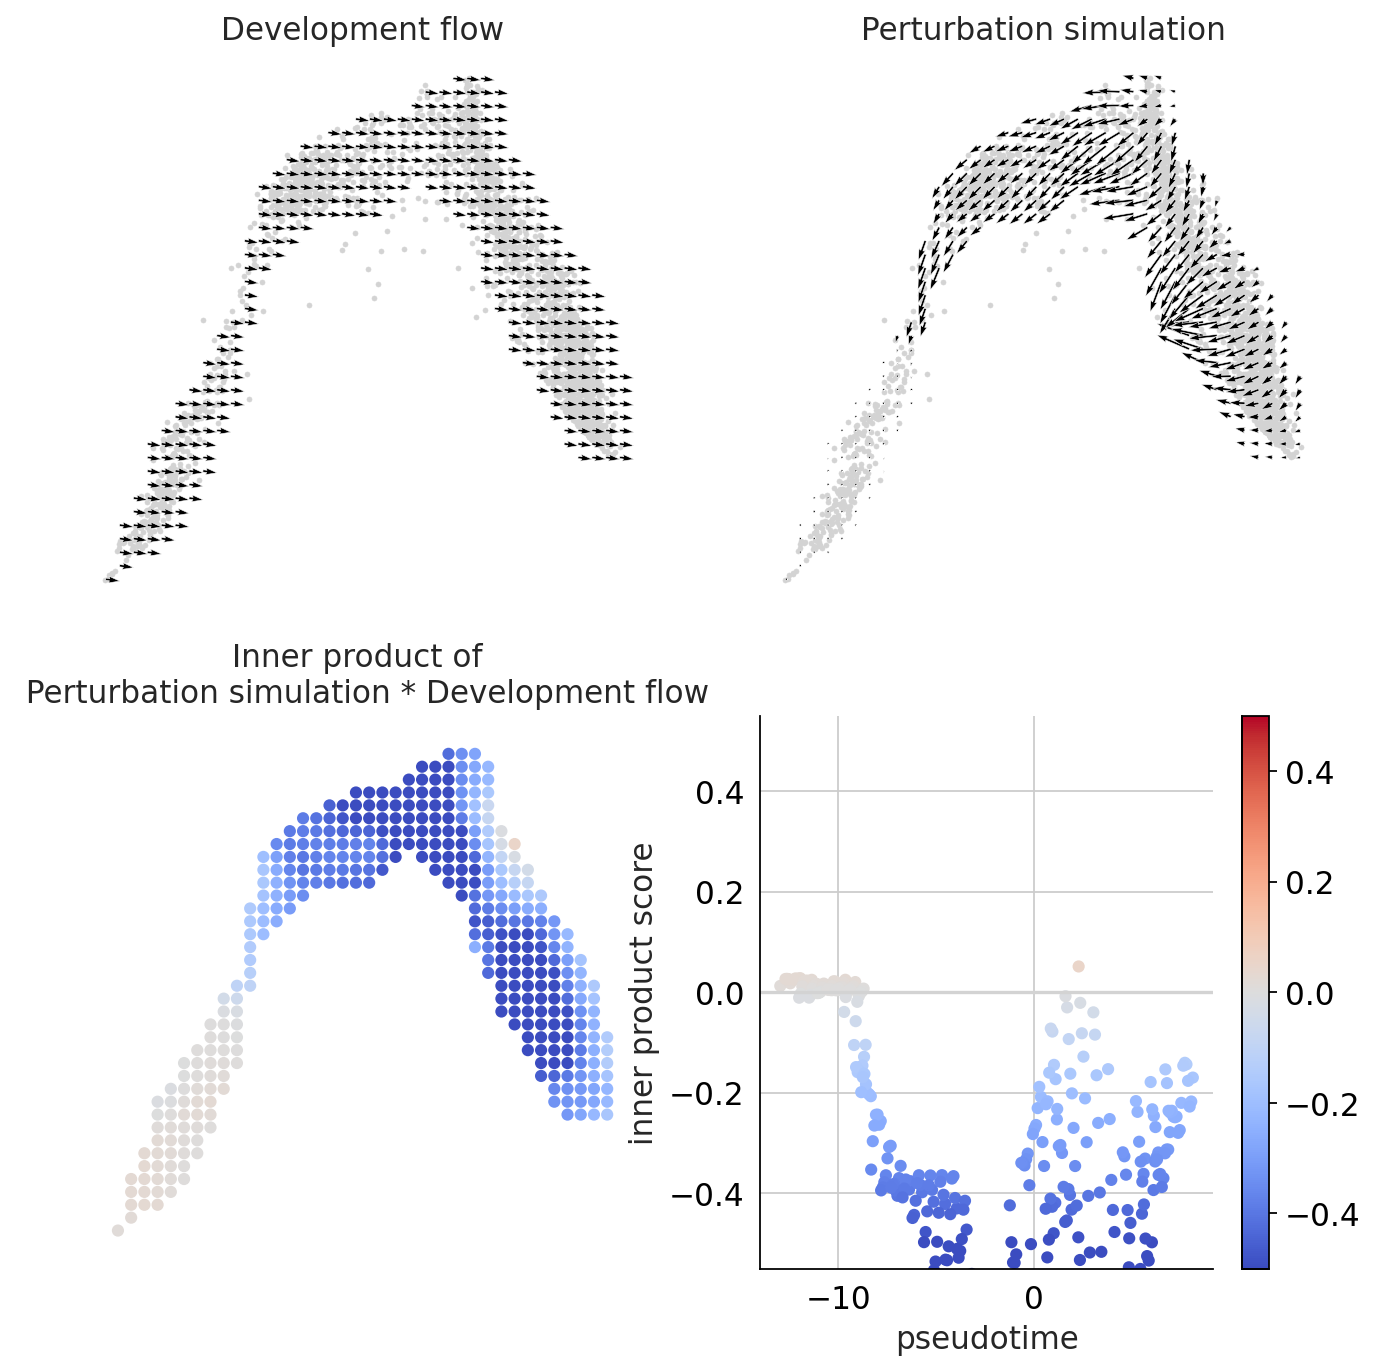

In [78]:
# Let's visualize the results 
visualize_simulation_module(dev,s=5, 
                                          scale_for_simulation=scale_simulation,
                                          s_grid=20,
                                          scale_for_pseudotime=scale_dev, 
                                          vm=0.5)

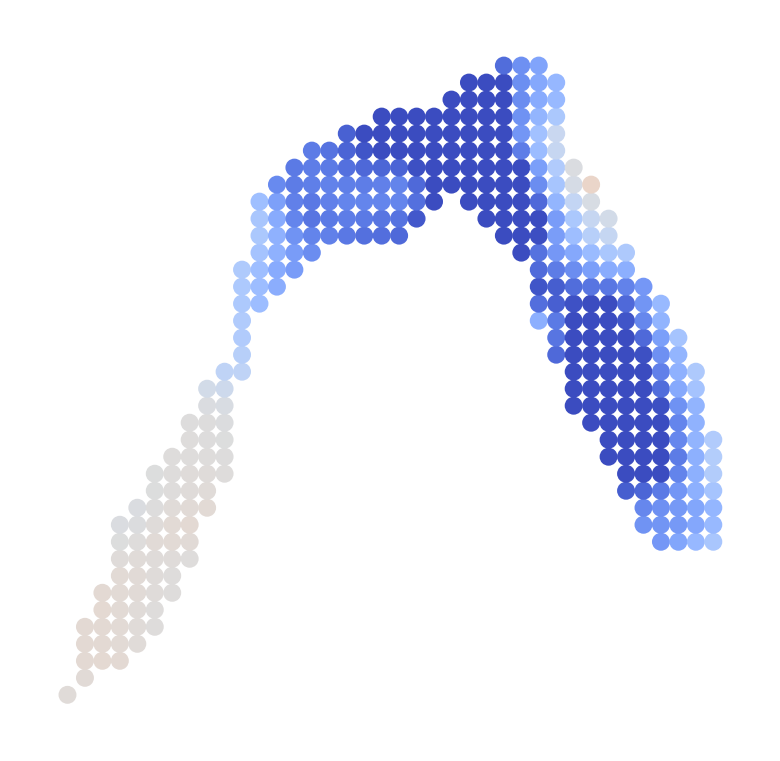

In [62]:
# Show inner product score
fig, ax = plt.subplots(figsize=[6, 6])
dev.plot_inner_product_on_grid(vm=0.5, s=50, ax=ax)

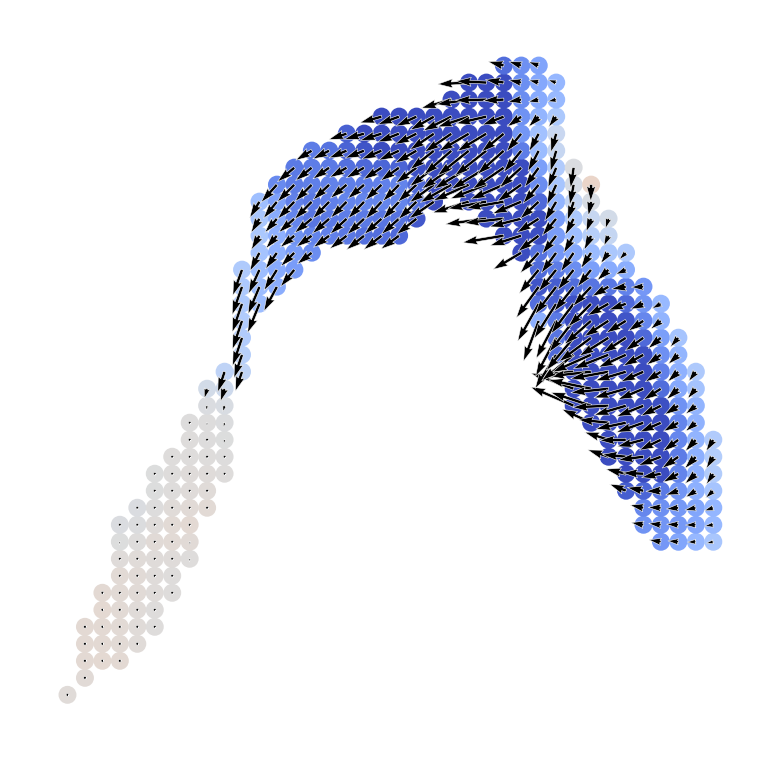

In [64]:
# Show inner product score with perturbation simulation vector field
fig, ax = plt.subplots(figsize=[6, 6])
dev.plot_inner_product_on_grid(vm=0.5, s=50, ax=ax)
dev.plot_simulation_flow_on_grid(scale=scale_simulation, show_background=False, ax=ax)

# 6. Focus on a single development lineage to interpret the results in detail

So far, we have used `Oracle_development_module` to analyze the whole cell population.
If you input the index for the cells of interest, Oracle_development_module will analyze subset data.


In [79]:
# Get cell index list for the cells of interest
clusters = ['Erythroid1','Erythroid2','Erythroid3']
cell_idx = np.where(oracle.adata.obs["celltype.mapped"].isin(clusters))[0]

# Check 
print(cell_idx)

[ 830  840  913 ... 2439 2440 2441]


In [80]:
dev = Oracle_development_module()
# Load development flow

In [81]:
dev.load_differentiation_reference_data(gradient_object=gradient)

# Load simulation result
dev.load_perturb_simulation_data(oracle_object=oracle, 
                                 cell_idx_use=cell_idx, # Enter cell id list
                                 name="Erythroid" # Name of this cell group. You can enter arbitrary name.
                                 )

# Calculate stats
dev.calculate_inner_product()
dev.calculate_digitized_ip(n_bins=10)

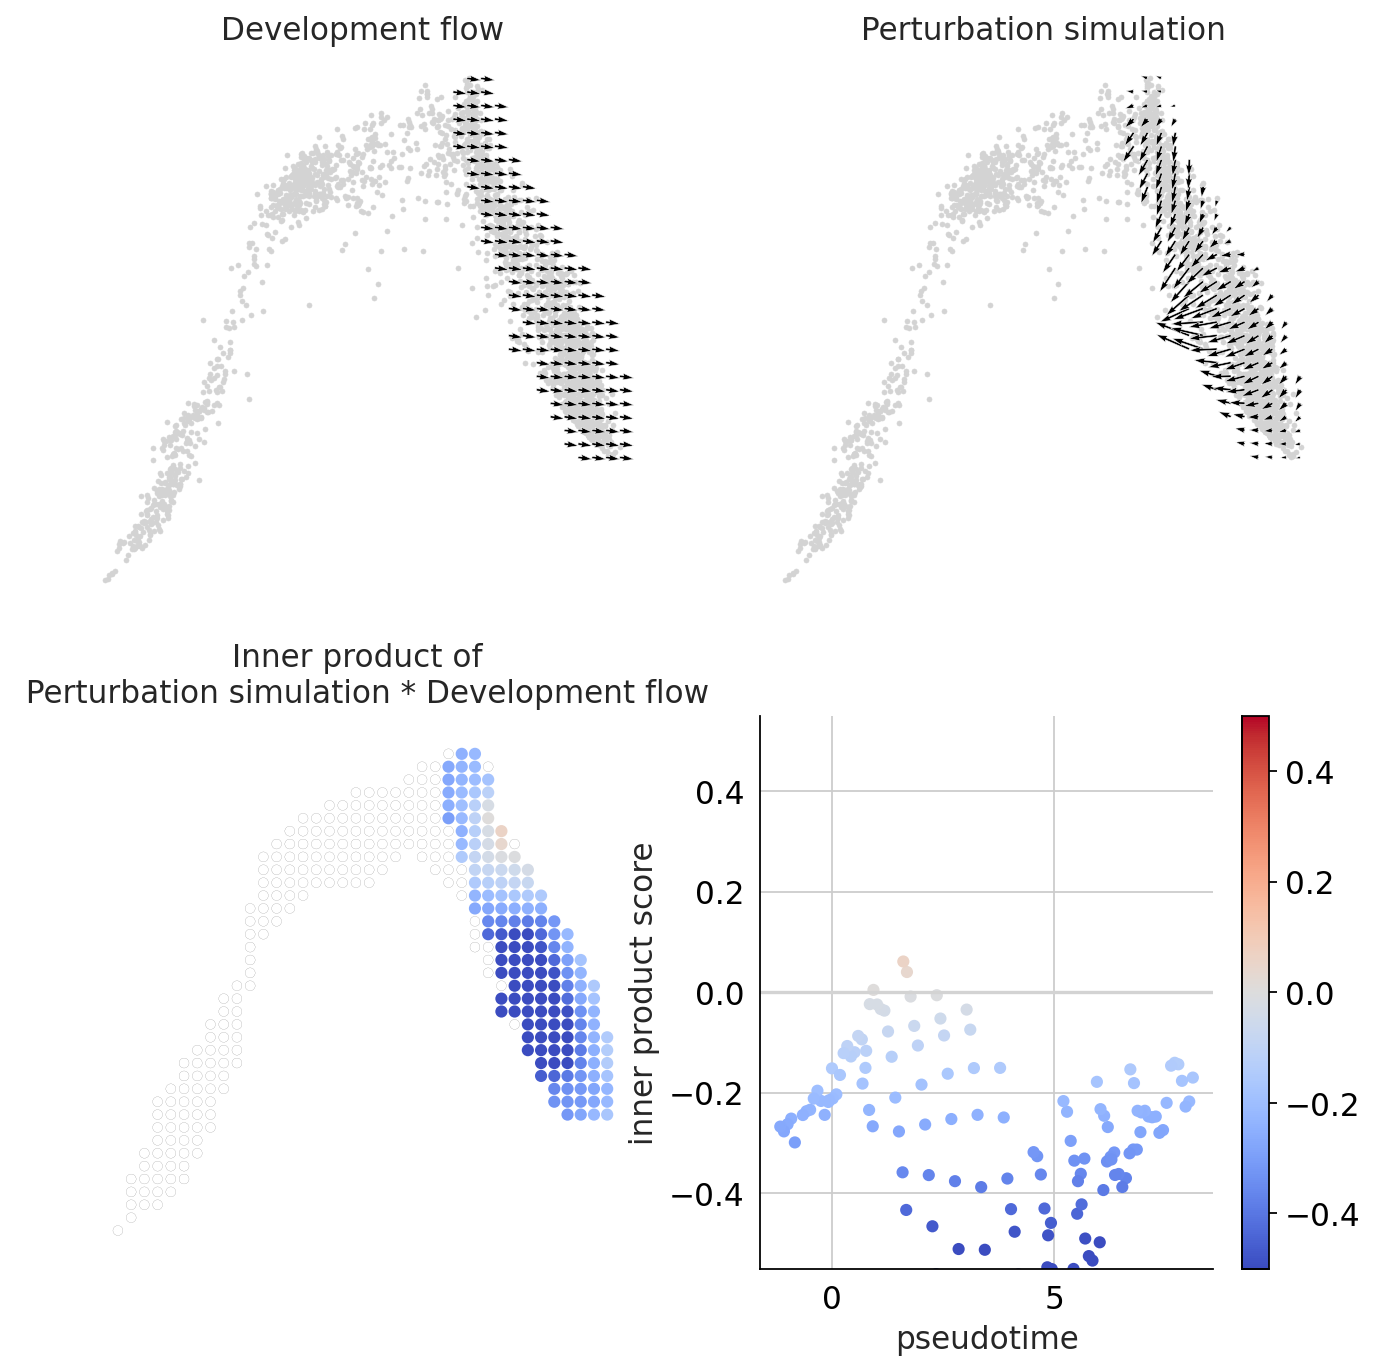

In [82]:
# Let's visualize the results 
visualize_simulation_module(dev,s=5, 
                              scale_for_simulation=scale_simulation,
                              s_grid=20,
                              scale_for_pseudotime=scale_dev, 
                              vm=0.5)